In [1]:
from pathlib import Path
from dataclasses import dataclass, field
from pprint import pprint
import pickle as pkl
from typing import Literal

import matplotlib.pylab as plt
from matplotlib.axes._axes import Axes
import numpy as np

from HexLatticePlot import HexCell, HexLattice, Coordinate, AxialCoordinate, DoubleWidthCoordinate, PlotConfig, ValidDirections
from HexLatticePlot.coordinates import AbstractCoordinate


In [2]:
@dataclass
class SmdfrCoordinate(AbstractCoordinate):
    u: int = 0
    v: int = 0
    name: str = field(default='smdfr', init=False, repr=False)

    @staticmethod
    def coord_is_valid(coord) -> bool:
        return len(coord) == 2 and all(isinstance(x, int) for x in coord)

    def __init__(self, *args) -> None:
        if len(args) == 1 and isinstance(args[0], (tuple, list)) and len(args[0]) == 2:
            self.u, self.v = args[0]
        elif len(args) == 2 and all(isinstance(arg, int) for arg in args):
            self.u, self.v = args
        else:
            raise TypeError(f'Invalid arguments: {args}')

    def convert_to_axial(self) -> AxialCoordinate:
        x = self.u + self.v
        z = -self.v
        return AxialCoordinate(x, z)

    @staticmethod
    def converted_from_axial(axial_coord: AxialCoordinate) -> 'SmdfrCoordinate':
        u = axial_coord.x + axial_coord.z
        v = -axial_coord.z
        return SmdfrCoordinate(u, v)


In [3]:
def coord_is_valid(coord: Coordinate | AbstractCoordinate) -> bool:
    """
    判断坐标是否在扇形区域内。
    要求：半径小于等于15，且角度在0到60度之间（以x轴正方向为0度）。
    """
    x, y = coord.cartesian.x, coord.cartesian.y
    r2 = x ** 2 + y ** 2
    if r2 > 15 ** 2:
        return False
    theta = np.arctan2(y, x)  # 弧度
    if 0 <= theta <= (np.pi / 3)*1.001:
        return True
    return False

In [4]:
smdfr: list[Coordinate] = list()
wait_list = list()
wait_list.append(Coordinate(SmdfrCoordinate(0, 0)))
while wait_list:
    pop_coord: Coordinate = wait_list.pop()

    # 如果坐标在半径内加入smdfr
    if coord_is_valid(pop_coord) and (pop_coord not in smdfr):
        smdfr.append(pop_coord)
        
    # 将合法的坐标的邻居加入等待列表
    for coord in pop_coord.get_all_neighbour():
        if coord_is_valid(coord) and (coord not in smdfr):
            wait_list.append(coord)


In [5]:
print(len(smdfr))

153


In [7]:
hexcell_list: list[HexCell] = []
for coord in smdfr:
    u, v = coord.smdfr.as_tuple()
    coord_text = f'({u}, {v})'
    hexcell_list.append(HexCell(coord, text=coord_text))
hl = HexLattice(hexcell_list)

## Write data into HexCells

## Plot

In [8]:
pc = PlotConfig('smDFR coordinates in axial system')
pc.image_root_dir = Path('examples/plot')
pc.image_type = 'png'
pc.plot_style = 'bmh'
pc.hex_face_color = "#fdf3ee"

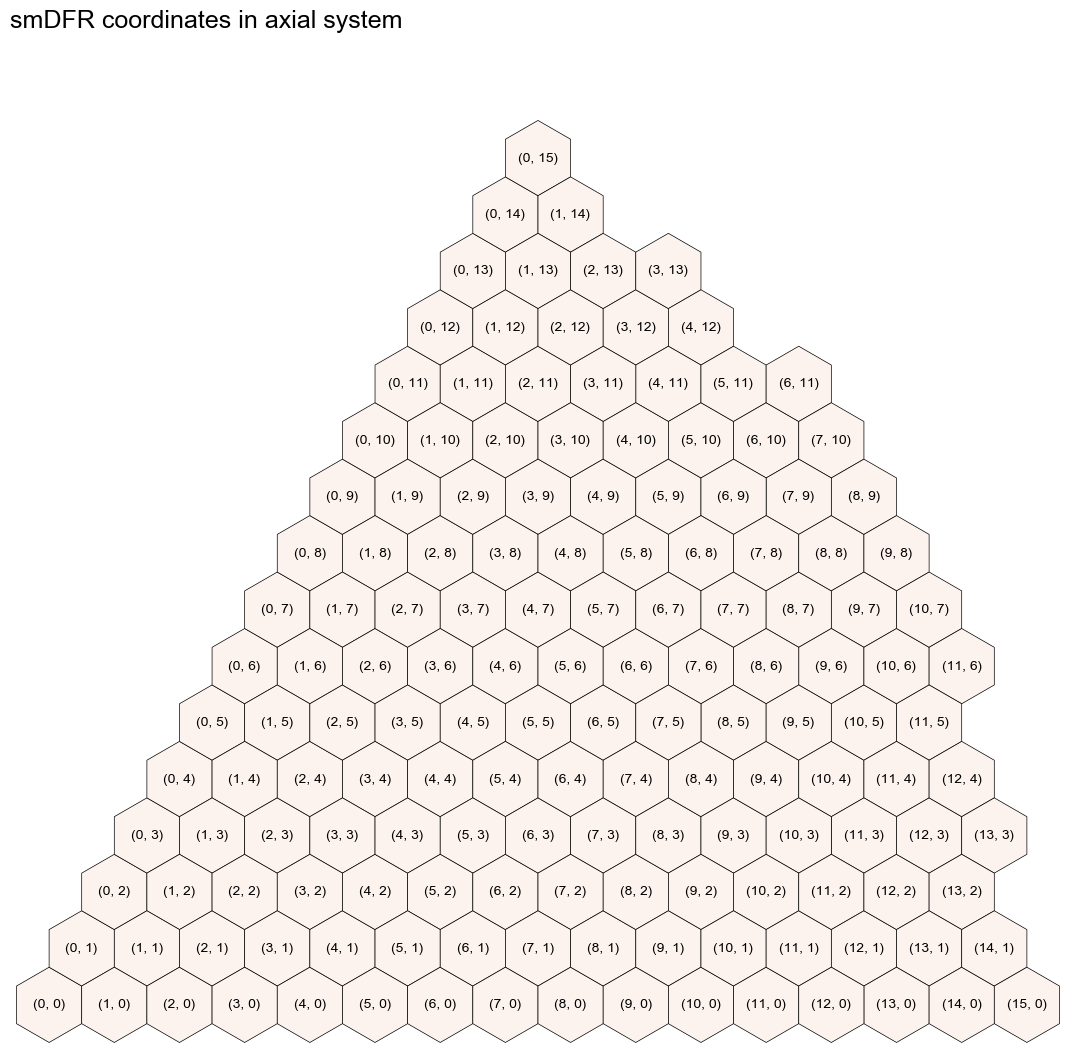

In [9]:
ax, _ = hl.plot(
    pc,
    shape="hex",
    text_mode="text",
    save=True,
    show=True,
    close=True,
)